In [3]:
!pip install numpy matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

   Exp  TrainHours  WorkHours  Projects  ProductivityScore
0    2          40         38         3                 62
1    4          60         42         6                 78
2    1          20         35         2                 55
3    8          80         45         8                 88
4   11          65         40         5                 72

Shape: (10, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Exp                10 non-null     int64
 1   TrainHours         10 non-null     int64
 2   WorkHours          10 non-null     int64
 3   Projects           10 non-null     int64
 4   ProductivityScore  10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes
             Exp  TrainHours  WorkHours  Projects  ProductivityScore
count  10.000000    10.00000  10.000000  10.00000          10.000000
mean    5.500000    55.500

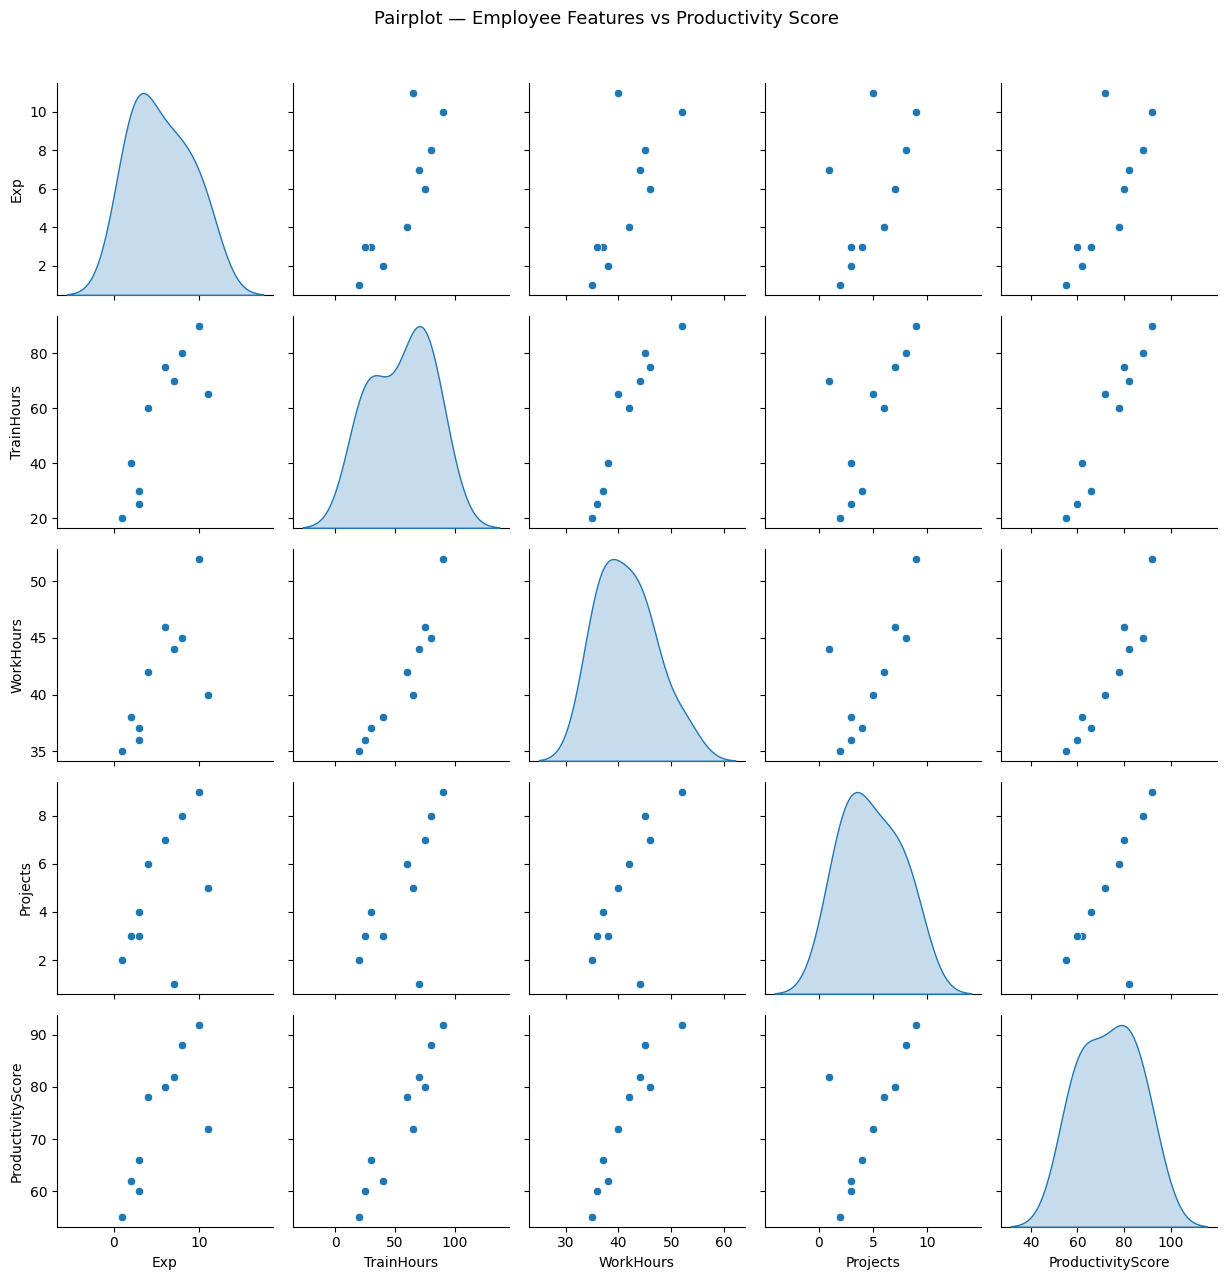

X_train_scaled [[-0.87652306 -0.31976474 -0.35575624 -0.33709993]
 [ 0.58434871  1.02324717  1.30443953 -1.28097974]
 [-1.16869742 -1.21510601 -1.18585412 -0.80903983]
 [-0.58434871 -0.99127069 -0.90915483 -0.33709993]
 [ 1.75304613  0.79941185  0.19764235  0.60677988]
 [ 0.87652306  1.4709178   1.58113883  2.02259959]
 [-0.58434871 -0.76743538 -0.63245553  0.13483997]]

Intercept: 69.2857

MSE : 394.4923
RMSE: 19.8618
R²  : -9.3210

Prediction Results:
 Actual  Predicted
     80      93.17
     78      76.86
     92     123.76


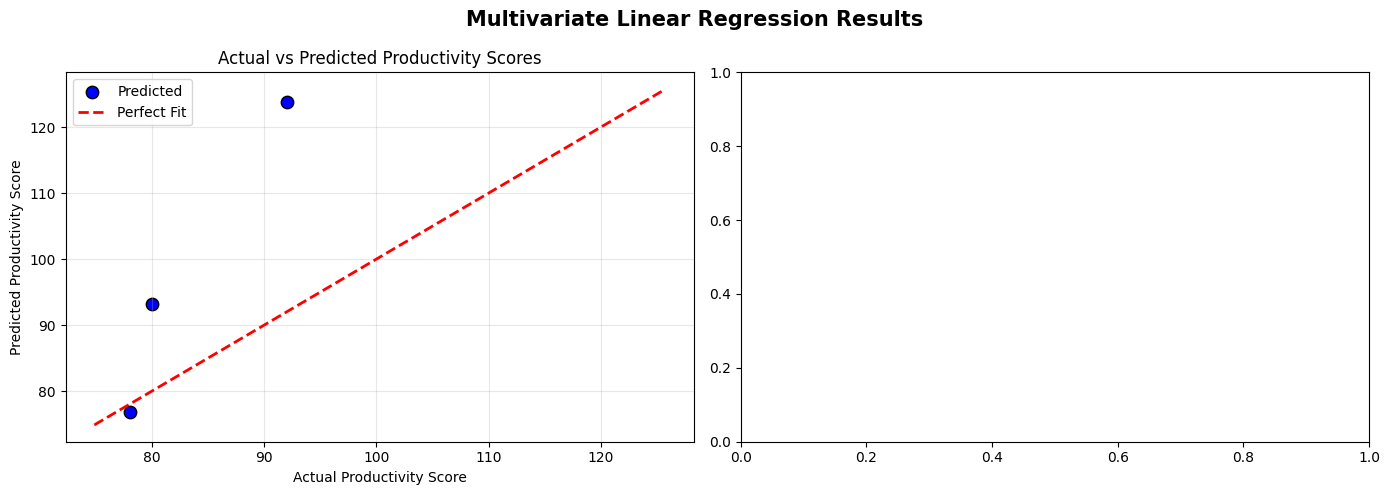

In [6]:
input_data = {
    "Exp": [2, 4, 1, 8, 11, 10, 3, 7,6,3],
    "TrainHours": [40, 60, 20, 80, 65, 90, 30, 70, 75,25],
    "WorkHours": [38, 42, 35, 45, 40, 52, 37, 44, 46, 36],
    "Projects": [3, 6, 2, 8, 5, 9, 4, 1, 7,3],
    "ProductivityScore": [62, 78, 55, 88, 72, 92, 66, 82,80,60],
}

df = pd.DataFrame(input_data)

print(df.head())
print(f"\nShape: {df.shape}")
df.info()
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

sns.pairplot(df, diag_kind="kde")
plt.suptitle("Pairplot — Employee Features vs Productivity Score", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

X = df[["Exp", "TrainHours", "WorkHours", "Projects"]]
y = df["ProductivityScore"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled", X_train_scaled)
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"\nIntercept: {model.intercept_:.4f}")

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nMSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(y_pred, 2)
})
print("\nPrediction Results:")
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Multivariate Linear Regression Results", fontsize=15, fontweight="bold")

# actual vs predicted
axes[0].scatter(y_test, y_pred, color="blue", edgecolors="black", s=80, label="Predicted")
min_val = min(y_test.min(), y_pred.min()) - 2
max_val = max(y_test.max(), y_pred.max()) + 2
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect Fit")

axes[0].set_xlabel("Actual Productivity Score")
axes[0].set_ylabel("Predicted Productivity Score")
axes[0].set_title("Actual vs Predicted Productivity Scores")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()